# ED Boarding Project Midway Report

Compares three baseline agents on the Emergency Department simulation:

- **Random**: picks a random action each step
- **FCFS**: First Come First Served, admits the oldest patient first
- **Acuity First**: always admits the highest acuity patient first

Each agent runs for 10 episodes. Results are shown as a summary table and two plots.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ed_env import EmergencyDeptEnv, BED_CAPACITY, EPISODE_LENGTH
from baselines import RandomAgent, FCFSAgent, AcuityFirstAgent

## Helper Functions

`run_episode`: 
- runs a 24 hour episode and returns metrics each step

`run_agent`:
- runs agent for multiple episodes and averages results

In [16]:
def run_episode(env, agent):
    # reset environemnt
    obs, _ = env.reset()

    # Set up variables to keep track of metrics
    rewards = []
    queue_lengths = []
    bed_occupancy = []
    total_beds = sum(BED_CAPACITY.values())

    # Build a list for each ESI level to track longest wait at each step
    esi_max_waits = {}
    for esi in range(1, 6):
        esi_max_waits[esi] = []

    terminated = False
    truncated = False
    # Loop while the episode is not over
    while not (terminated or truncated):
        # Select an action for the given agent
        # RandomAgent doesnt need an environment, others do
        if isinstance(agent, RandomAgent):
            action = agent.select_action()
        else:
            action = agent.select_action(env)

        # Take a step, store results
        obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(reward)
        queue_lengths.append(info["queue_length"])

        # Track num patients in bed
        patients_in_beds = 0
        for b in env.beds:
            patients_in_beds += len(env.beds[b])
        # Fraction of all beds occupied
        bed_occupancy.append(patients_in_beds / total_beds)

        # For each ESI group record the longest current wait
        for esi in range(1, 6):
            waits = []
            for p in env.waiting_queue:
                if p.esi == esi:
                    waits.append(p.steps_waiting(env.current_step))
            if len(waits) > 0:
                esi_max_waits[esi].append(max(waits))
            else:
                esi_max_waits[esi].append(0)

    return {
        "rewards": rewards,
        "queue_lengths": queue_lengths,
        "bed_occupancy": bed_occupancy,
        "esi_max_waits": esi_max_waits,
        "total_discharged": info["total_discharged"],
        "total_lwbs": info["total_lwbs"],
    }


def run_agent(agent, num_episodes=10):
    # Run multiple episodes
    env = EmergencyDeptEnv()
    all_episodes = []
    # Loop through number of episodes, call run_epsisode and store results
    for _ in range(num_episodes):
        all_episodes.append(run_episode(env, agent))

    # Take average of ESI wait times across epsisodes
    avg_esi_waits = {}
    for esi in range(1, 6):
        esi_data = [ep["esi_max_waits"][esi] for ep in all_episodes]
        avg_esi_waits[esi] = np.mean(esi_data, axis=0)

    # Returned averaged results
    return {
        "avg_rewards": np.mean([ep["rewards"] for ep in all_episodes], axis=0),
        "avg_queue": np.mean([ep["queue_lengths"] for ep in all_episodes], axis=0),
        "avg_occupancy": np.mean([ep["bed_occupancy"] for ep in all_episodes], axis=0),
        "avg_esi_waits": avg_esi_waits,
        "mean_discharged": np.mean([ep["total_discharged"] for ep in all_episodes]),
        "mean_lwbs": np.mean([ep["total_lwbs"] for ep in all_episodes]),
    }

In [19]:
print("Running Random Agent")
random_results = run_agent(RandomAgent(EmergencyDeptEnv().action_space))

print("Running FCFS Agent")
fcfs_results = run_agent(FCFSAgent())

print("Running Acuity First Agent")
acuity_results = run_agent(AcuityFirstAgent())

print("\nDone.")

agents = {
    "Random": random_results,
    "FCFS": fcfs_results,
    "Acuity First": acuity_results,
}

Running Random Agent
Running FCFS Agent
Running Acuity First Agent

Done.


## Results

In [20]:
# Display results in pandas dataframe

rows = []
for name, results in agents.items():
    row = {}
    row["Agent"] = name
    row["Mean Discharges"] = round(results["mean_discharged"], 1)
    row["Mean LWBS"] = round(results["mean_lwbs"], 1)
    row["Mean Bed Occupancy"] = f"{results['avg_occupancy'].mean() * 100}%"
    row["Total Reward"] = round(results["avg_rewards"].sum(), 1)
    for esi in range(1, 6):
        col_name = f"ESI {esi} Max Wait (steps)"
        row[col_name] = round(results["avg_esi_waits"][esi].mean(), 2)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Agent")
df

,Mean Discharges,Mean LWBS,Mean Bed Occupancy,Total Reward,ESI 1 Max Wait (steps),ESI 2 Max Wait (steps),ESI 3 Max Wait (steps),ESI 4 Max Wait (steps),ESI 5 Max Wait (steps)
Agent,,,,,,,,,
Random,47.7,77.7,20.179398148148145%,-8412.9,6.22,11.98,13.31,4.88,0.29
FCFS,72.4,36.4,33.53780864197531%,-7311.9,5.46,11.25,11.98,5.72,0.14
Acuity First,72.0,46.1,35.48996913580247%,-2631.9,0.12,1.99,12.18,6.76,0.22


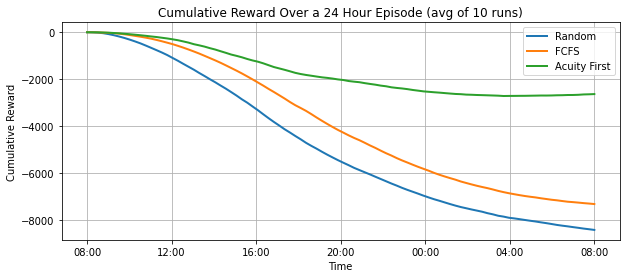

In [34]:
# Plot 1: Cumulative reward over 24 hour episode (avg of 10 runs)

steps = np.arange(1, EPISODE_LENGTH + 1)

# Convert the step number to time of day with start at 8 AM
def step_to_hour(step):
    return (8 + step * 0.25) % 24

# Create some x lables based on the step index
x_labels = []
for s in [0, 16, 32, 48, 64, 80, 96]:
    hour = int(step_to_hour(s))
    x_labels.append(f"{hour:02d}:00")

fig, ax = plt.subplots(figsize=(10, 4))
# Loop through the different agents results
for name, results in agents.items():
    # Calculate cumulative reward
    cumulative = np.cumsum(results["avg_rewards"])
    ax.plot(steps, cumulative, label=name, linewidth=2)

ax.set_title("Cumulative Reward Over a 24 Hour Episode (avg of 10 runs)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Reward")
# Need set_xticks to add the x labels
ax.set_xticks(np.linspace(1, 96, 7))
ax.set_xticklabels(x_labels)
ax.legend()
ax.grid(True)
plt.show()

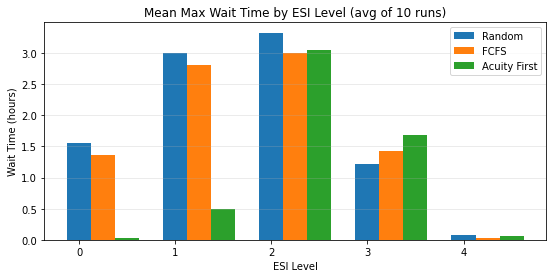

In [33]:
# Plot 2: Mean max wait time by ESI level

# Set up groups 
esi_levels = ["ESI 1", "ESI 2", "ESI 3", "ESI 4", "ESI 5"]
x = np.arange(len(esi_levels))
bar_width = 0.25

# initialize plot and size
fig, ax = plt.subplots(figsize=(9, 4))
# Loop through different agents results
for i, (name, results) in enumerate(agents.items()):
    means = []
    # For each ESI level, get the average max wait time
    for esi in range(1, 6):
        means.append(results["avg_esi_waits"][esi].mean() * 0.25)
    # Create the bar with this mean
    ax.bar(x + i * bar_width, means, width=bar_width, label=name)

ax.set_title("Mean Max Wait Time by ESI Level (avg of 10 runs)")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Wait Time (hours)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()